In [18]:
import     pandas     as     pd

# 1. Ler as duas planilhas do Excel
df1 = pd.read_excel(    'dados_1.xlsx'    )
df2 = pd.read_excel(    'dados_2.xlsx'    )

# 2. Juntar as duas lado a lado (mantendo a ordem     exata das linhas)
dados_completos = pd.concat([df1, df2], axis=    1    )

# 3. Mostre as primeiras linhas para confirmar se     deu certo
dados_completos.head()

,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_STATUS_REDACAO,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_REDACAO,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,SG_UF_PROVA,Q002,Q020
0,CE,2.0,1.0,60.0,60.0,80.0,300.0,210062064233,5,F,1,1,RS,F,B
1,SC,4.0,1.0,200.0,200.0,180.0,920.0,210062064234,11,F,1,1,RS,C,B
2,NaN,NaN,1.0,120.0,40.0,120.0,480.0,210062064235,11,F,1,1,RS,F,B
3,NaN,NaN,1.0,200.0,160.0,160.0,740.0,210062064236,3,F,3,2,RS,B,B
4,MA,2.0,NaN,NaN,NaN,NaN,NaN,210062064237,16,M,1,1,RS,B,B


In [19]:
# 1. Manter apenas candidatos com redação corrigida regularmente (Status = 1)
dados_limpos = dados_completos[dados_completos['TP_STATUS_REDACAO'] == 1].copy()

# 2. Filtrar para manter APENAS o estado de Minas Gerais (MG)
dados_limpos = dados_limpos[dados_limpos['SG_UF_ESC'] == 'MG']

# 3. Filtrar para garantir que não temos notas zeradas na redação
dados_limpos = dados_limpos[dados_limpos['NU_NOTA_REDACAO'] > 0]

# 4. Eliminar qualquer linha com dados em branco (valores nulos) em toda a base
dados_limpos = dados_limpos.dropna()

# 5. Mostrar o resultado final do corte
print(f"Quantidade de registros de MG após a limpeza: {dados_limpos.shape[0]}")
dados_limpos.head()

Quantidade de registros de MG após a limpeza: 24902


,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_STATUS_REDACAO,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_REDACAO,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,SG_UF_PROVA,Q002,Q020
67,MG,4.0,1.0,180.0,200.0,180.0,920.0,210062064418,6,F,3,1,BA,E,B
82,MG,2.0,1.0,200.0,160.0,180.0,920.0,210062064433,3,F,3,3,RS,E,B
101,MG,2.0,1.0,160.0,140.0,140.0,760.0,210062064502,17,F,3,1,RS,C,B
118,MG,2.0,1.0,140.0,120.0,120.0,540.0,210062064519,16,F,1,1,RS,D,B
134,MG,4.0,1.0,140.0,140.0,180.0,760.0,210062064538,11,M,1,1,SP,F,B


In [20]:
# 1. Remover colunas de controle que não serão usadas no treinamento do ANFIS
colunas_para_remover = ['SG_UF_ESC', 'TP_STATUS_REDACAO']
dados_modelagem = dados_limpos.drop(columns=colunas_para_remover)

# 2. Identificar quais colunas ainda possuem textos (tipo 'object')
colunas_texto = dados_modelagem.select_dtypes(include=['object']).columns

# 3. Transformar os textos em números (0, 1, 2...) de forma automática
for col in colunas_texto:
    dados_modelagem[col] = dados_modelagem[col].astype('category').cat.codes

# 4. Mostrar o resultado final pronto para a Inteligência Artificial
print("Base de dados totalmente numérica para o ANFIS:")
dados_modelagem.head()

Base de dados totalmente numérica para o ANFIS:


,TP_DEPENDENCIA_ADM_ESC,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_REDACAO,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,SG_UF_PROVA,Q002,Q020
67,4.0,180.0,200.0,180.0,920.0,210062064418,6,0,3,1,4,4,1
82,2.0,200.0,160.0,180.0,920.0,210062064433,3,0,3,3,22,4,1
101,2.0,160.0,140.0,140.0,760.0,210062064502,17,0,3,1,22,2,1
118,2.0,140.0,120.0,120.0,540.0,210062064519,16,0,1,1,22,3,1
134,4.0,140.0,140.0,180.0,760.0,210062064538,11,1,1,1,25,5,1


Número Total de Alunos: 24902
Amostras para Treinamento (80%):    19921
Amostras para Teste (20%): 4981
Variáveis de entrada selecionadas:        ['TP_DEPENDENCIA_ADM_ESC', 'Q002', 'Q020']

PARAMETROS OTIMIZADOS
Quantidade de parametros: 21
[1.39803919e+00 9.92561189e-01 1.96504887e+00 9.08693510e-01
 3.35671603e+00 1.00578121e+00 1.92666831e+00 1.30662567e+00
 3.55472877e+00 2.20968253e+00 4.13130450e+00 1.49753129e+00
 1.22674231e+00 2.89829473e-01 8.81458727e-01 3.70222923e-01
 9.78029327e-01 3.28942215e-01 3.61449133e+02 6.85189683e+02
 8.94831973e+02]

   RESULTADO DO DESEMPENHO DO MODELO ANFIS (ENEM)
ANFIS (parâmetros iniciais) -> MSE: 58437.93 | R²: -1.28896
ANFIS (treinado)            -> MSE: 26162.26 | R²: -0.02475


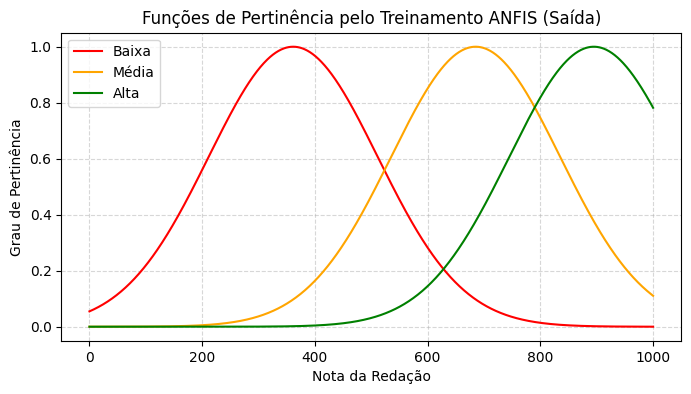

In [21]:
!pip install scikit-fuzzy
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize


#_____________ SAIDAS _____________
y_anfis = dados_modelagem['NU_NOTA_REDACAO'].values

nota_redacao = ctrl.Consequent(np.arange(0, 1001, 1), 'nota_redacao')
nota_redacao.automf(3, names=['baixa', 'media', 'alta'])


#_______________ ENTRADAS  _______________
X_anfis = dados_modelagem.drop(columns=['NU_NOTA_REDACAO'])

colunas_limpas = []
for col in X_anfis.columns:
    col_upper = col.upper()
    if "NOTA" in col_upper or "INSCRICAO" in col_upper or "ID" in col_upper or "COMP" in col_upper:
        continue
    colunas_limpas.append(col)

X_anfis_filtrado = X_anfis[colunas_limpas].copy()

# SELEÇÃO MANUAL: Tipo de Escola, Escolaridade da Mãe (Q002) e Internet (Q020)
melhores_colunas = ['TP_DEPENDENCIA_ADM_ESC', 'Q002', 'Q020']
X_anfis_otimizado = X_anfis_filtrado[melhores_colunas].values


#_______________ ESTRUTURA ANFIS E FUNÇÕES DE PERTINÊNCIA _______________
parametros_iniciais = []

for j in range(len(melhores_colunas)):
    col_data = X_anfis_otimizado[:, j]

    c1 = np.percentile(col_data, 20)
    c2 = np.percentile(col_data, 50)
    c3 = np.percentile(col_data, 80)

    sigma = np.std(col_data) if np.std(col_data) > 0 else 1.0

    parametros_iniciais.extend([
        c1, sigma,
        c2, sigma,
        c3, sigma
    ])

pesos_consequentes_iniciais = [300.0, 550.0, 850.0]
params_totais_iniciais = parametros_iniciais + pesos_consequentes_iniciais

def forward_anfis(params, X):
    num_alunos = X.shape[0]
    preds = np.zeros(num_alunos)

    p_fuzzy = params[:-3]
    p_consequente = params[-3:]

    for i in range(num_alunos):
        graus_regra = []
        for j in range(len(melhores_colunas)):
            val = X[i, j]
            idx = j * 6
            mu1 = fuzz.gaussmf(val, p_fuzzy[idx], p_fuzzy[idx+1])
            mu2 = fuzz.gaussmf(val, p_fuzzy[idx+2], p_fuzzy[idx+3])
            mu3 = fuzz.gaussmf(val, p_fuzzy[idx+4], p_fuzzy[idx+5])
            graus_regra.append([mu1, mu2, mu3])

        forca_baixa = graus_regra[0][0] * graus_regra[1][0] * (graus_regra[2][0] if len(melhores_colunas) > 2 else 1)
        forca_media = graus_regra[0][1] * graus_regra[1][1] * (graus_regra[2][1] if len(melhores_colunas) > 2 else 1)
        forca_alta = graus_regra[0][2] * graus_regra[1][2] * (graus_regra[2][2] if len(melhores_colunas) > 2 else 1)

        soma_forcas = forca_baixa + forca_media + forca_alta

        if soma_forcas > 0:
            preds[i] = ((forca_baixa * p_consequente[0]) +
                        (forca_media * p_consequente[1]) +
                        (forca_alta * p_consequente[2])) / soma_forcas
        else:
            preds[i] = 500.0

    return preds

def funcao_custo_anfis(params, X, y):
    preds = forward_anfis(params, X)
    return mean_squared_error(y, preds)


#_______________ TESTE VS TREINO _______________
total_amostras = len(X_anfis_otimizado)
tamanho_treino = int(total_amostras * 0.80)
tamanho_teste = total_amostras - tamanho_treino

X_treino, X_teste = X_anfis_otimizado[:tamanho_treino], X_anfis_otimizado[tamanho_treino:]
y_treino, y_teste = y_anfis[:tamanho_treino], y_anfis[tamanho_treino:]

print("="*60)
print(f"Número Total de Alunos: {total_amostras}")
print(f"Amostras para Treinamento (80%):    {tamanho_treino}")
print(f"Amostras para Teste (20%): {tamanho_teste}")
print(f"Variáveis de entrada selecionadas:        {melhores_colunas}")
print("="*60)

# Avaliação inicial antes do treino
preds_iniciais = forward_anfis(params_totais_iniciais, X_teste)
preds_iniciais = np.clip(preds_iniciais, 0, 1000)
mse_inicial = mean_squared_error(y_teste, preds_iniciais)
r2_inicial = r2_score(y_teste, preds_iniciais)


#_______________ ALGORITMO DE TREINAMENTO (REDE NEURAL) _______________
resultado_treino = minimize(
    funcao_custo_anfis,
    params_totais_iniciais,
    args=(X_treino, y_treino),
    method='Nelder-Mead',
    options={'maxiter': 120}
)

parametros_otimizados = resultado_treino.x

print("\n" + "="*60)
print("PARAMETROS OTIMIZADOS")
print("="*60)
print("Quantidade de parametros:", len(parametros_otimizados))
print(parametros_otimizados)
print("="*60)


#_______________ ANÁLISE DE ERRO (MÉTRICAS FINAIS) _______________
notas_preditas = forward_anfis(parametros_otimizados, X_teste)
notas_preditas = np.clip(notas_preditas, 0, 1000)

mse_treinado = mean_squared_error(y_teste, notas_preditas)
r2_treinado = r2_score(y_teste, notas_preditas)

print("\n" + "="*60)
print("   RESULTADO DO DESEMPENHO DO MODELO ANFIS (ENEM)")
print("="*60)
print(f"ANFIS (parâmetros iniciais) -> MSE: {mse_inicial:.2f} | R²: {r2_inicial:.5f}")
print(f"ANFIS (treinado)            -> MSE: {mse_treinado:.2f} | R²: {r2_treinado:.5f}")
print("="*60)


#_______________ GRÁFICO _______________
plt.figure(figsize=(8, 4))
x_plot = np.linspace(0, 1000, 1000)

# Resgata os 3 últimos parâmetros sintonizados correspondentes aos centros das notas
plt.plot(x_plot, fuzz.gaussmf(x_plot, parametros_otimizados[-3], 150), label='Baixa', color='red')
plt.plot(x_plot, fuzz.gaussmf(x_plot, parametros_otimizados[-2], 150), label='Média', color='orange')
plt.plot(x_plot, fuzz.gaussmf(x_plot, parametros_otimizados[-1], 150), label='Alta', color='green')

plt.ylabel('Grau de Pertinência')
plt.xlabel('Nota da Redação')
plt.title('Funções de Pertinência pelo Treinamento ANFIS (Saída)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [22]:
# ================= FASE 2 - VALIDACAO DO CURSINHO  =================

import  numpy  as  np
import  pandas  as  pd
from  sklearn.metrics  import  mean_absolute_error, mean_squared_error, r2_score

# Matriz de entrada dos 11 alunos
# [TP_DEPENDENCIA_ADM_ESC, Q002, Q020]
X_cursinho = np.array([
    [ 2 , 4 , 1 ],   # Aluno 1 - Médio completo
    [ 2 , 1 , 1 ],   # Aluno 2 - Fundamental incompleto
    [ 2 , 5 , 1 ],   # Aluno 3 - Superior completo
    [ 2 , 3 , 1 ],   # Aluno 4 - Médio incompleto
    [ 2 , 4 , 1 ],   # Aluno 5 - Médio completo
    [ 2 , 4 , 1 ],   # Aluno 6 - Médio completo
    [ 2 , 4 , 1 ],   # Aluno 7 - Médio completo
    [ 2 , 5 , 1 ],   # Aluno 8 - Superior completo
    [ 2 , 4 , 1 ],   # Aluno 9 - Médio completo
    [ 2 , 1 , 1 ],   #Aluno 10 - Fundamental incompleto
    [ 2 , 4 , 1 ]    # Aluno 11 - Médio completo
])

# Notas reais enem
notas_reais = np.array([ 720 ,  600 ,  760 ,  700 ,  840 , 720 ,  840 ,  880 ,  840 ,  600 ,  820 ])


# Previsões do ANFIS
notas_previstas = forward_anfis(parametros_otimizados, X_cursinho)

# Arredondamento para múltiplos de 20 (padrão ENEM)
notas_previstas = np.round(notas_previstas / 20) * 20
notas_previstas = notas_previstas.astype(int)

# Tabela comparativa
resultado = pd.DataFrame({ 'Aluno' :  range ( 1 ,  12 ), 'Nota_Real' : notas_reais, 'Nota_Prevista_ANFIS' : notas_previstas })





resultado[ 'Erro' ] = (
    resultado[ 'Nota_Prevista_ANFIS' ]
    - resultado[ 'Nota_Real' ]
)


# Métricas de validação
mae = mean_absolute_error(
    resultado[ 'Nota_Real' ],
    resultado[ 'Nota_Prevista_ANFIS' ]
)

mse = mean_squared_error(
    resultado[ 'Nota_Real' ],
    resultado[ 'Nota_Prevista_ANFIS' ]
)

r2 = r2_score(
    resultado[ 'Nota_Real' ],
    resultado[ 'Nota_Prevista_ANFIS' ]
)
resultado['Erro'] = (
    resultado['Nota_Prevista_ANFIS']
    - resultado['Nota_Real']
)

resultado['Erro_Absoluto'] = np.abs(resultado['Erro'])

erro_medio = resultado['Erro'].mean()
erro_relativo_medio = (erro_medio / np.mean(resultado['Nota_Real'])) * 100
# Erro relativo (%)
resultado['Erro_Relativo_%'] = (
    resultado['Erro_Absoluto'] /
    resultado['Nota_Real']
) * 100


print ( "VALIDAÇÃO DO MODELO ANFIS NO CURSINHO POPULAR" )
print ( "=" * 70 )
display(resultado)

print ( "\nMÉTRICAS DE DESEMPENHO" )
print ( f"MAE =  {mae :.2f} " )
print ( f"MSE =  {mse :.2f} " )
print ( f"R² =  {r2 :.4f} " )
print(f"Erro Relativo Médio = {erro_relativo_medio:.2f}%")

VALIDAÇÃO DO MODELO ANFIS NO CURSINHO POPULAR


,Aluno,Nota_Real,Nota_Prevista_ANFIS,Erro,Erro_Absoluto,Erro_Relativo_%
0,1,720,700,-20,20,2.777778
1,2,600,540,-60,60,10.000000
2,3,760,740,-20,20,2.631579
3,4,700,640,-60,60,8.571429
4,5,840,700,-140,140,16.666667
5,6,720,700,-20,20,2.777778
6,7,840,700,-140,140,16.666667
7,8,880,740,-140,140,15.909091
8,9,840,700,-140,140,16.666667
9,10,600,540,-60,60,10.000000



MÉTRICAS DE DESEMPENHO
MAE =  83.64 
MSE =  9527.27 
R² =  -0.1025 
Erro Relativo Médio = -11.06%


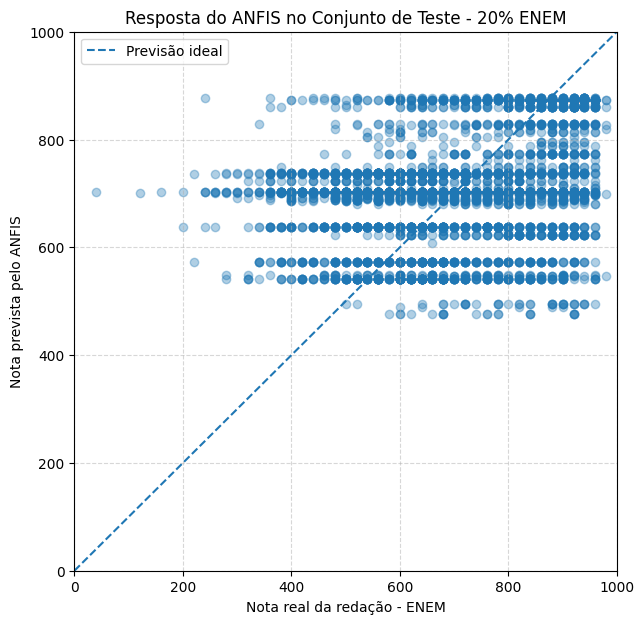

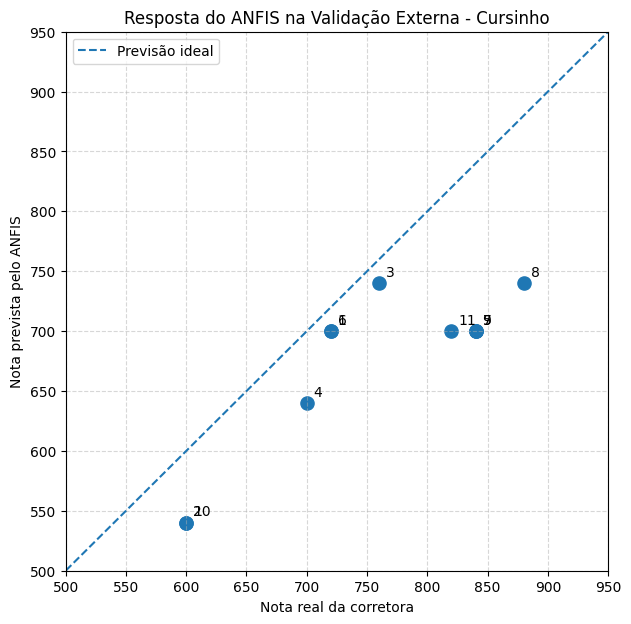

,Aluno,Nota_Real,Nota_ANFIS,Erro
0,1,720,700,-20
1,2,600,540,-60
2,3,760,740,-20
3,4,700,640,-60
4,5,840,700,-140
5,6,720,700,-20
6,7,840,700,-140
7,8,880,740,-140
8,9,840,700,-140
9,10,600,540,-60


In [23]:
# ========== GRÁFICOS REAL x PREVISTO ==========
# Gráfico 1: validação interna com 20% da base ENEM
# Gráfico 2: validação externa com os alunos do cursinho

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------- 1) TESTE COM 20% DA BASE ENEM ----------

pred_teste = forward_anfis(parametros_otimizados, X_teste)
pred_teste = np.clip(pred_teste, 0, 1000)

real_teste = y_teste

plt.figure(figsize=(7,7))
plt.scatter(real_teste, pred_teste, alpha=0.35)

plt.plot([0,1000], [0,1000], linestyle='--', label='Previsão ideal')

plt.title('Resposta do ANFIS no Conjunto de Teste - 20% ENEM')
plt.xlabel('Nota real da redação - ENEM')
plt.ylabel('Nota prevista pelo ANFIS')
plt.xlim(0,1000)
plt.ylim(0,1000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


# ---------- 2) VALIDAÇÃO COM OS 11 ALUNOS DO CURSINHO ----------

X_cursinho = np.array([
    [2,4,1],
    [2,1,1],
    [2,5,1],
    [2,3,1],
    [2,4,1],
    [2,4,1],
    [2,4,1],
    [2,5,1],
    [2,4,1],
    [2,1,1],
    [2,4,1]
])

notas_reais_cursinho = np.array([
    720, 600, 760, 700, 840,
    720, 840, 880, 840, 600, 820
])

pred_cursinho = forward_anfis(parametros_otimizados, X_cursinho)

# Arredondamento para múltiplos de 20, como no ENEM
pred_cursinho = np.round(pred_cursinho / 20) * 20
pred_cursinho = pred_cursinho.astype(int)

plt.figure(figsize=(7,7))
plt.scatter(notas_reais_cursinho, pred_cursinho, s=90)

plt.plot([0,1000], [0,1000], linestyle='--', label='Previsão ideal')

for i, (real, pred) in enumerate(zip(notas_reais_cursinho, pred_cursinho), start=1):
    plt.annotate(str(i), (real, pred), textcoords="offset points", xytext=(5,5))

plt.title('Resposta do ANFIS na Validação Externa - Cursinho')
plt.xlabel('Nota real da corretora')
plt.ylabel('Nota prevista pelo ANFIS')
plt.xlim(500,950)
plt.ylim(500,950)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


# ---------- TABELA AUXILIAR ----------

resultado_cursinho = pd.DataFrame({
    'Aluno': range(1,12),
    'Nota_Real': notas_reais_cursinho,
    'Nota_ANFIS': pred_cursinho,
    'Erro': pred_cursinho - notas_reais_cursinho
})

display(resultado_cursinho)

In [24]:
# Previsões no conjunto de teste (20%)
pred_teste = forward_anfis(parametros_otimizados, X_teste)
pred_teste = np.clip(pred_teste, 0, 1000)


# Previsões do cursinho
pred_cursinho = forward_anfis(parametros_otimizados, X_cursinho)
pred_cursinho = np.round(pred_cursinho / 20) * 20
pred_cursinho = pred_cursinho.astype(int)

# Métricas
mae_teste = mean_absolute_error(y_teste, pred_teste)
mse_teste = mean_squared_error(y_teste, pred_teste)
r2_teste = r2_score(y_teste, pred_teste)
erro_relativo_teste = np.mean(
    np.abs(pred_teste - y_teste) / y_teste
) * 100

mae_cursinho = mean_absolute_error(notas_reais, pred_cursinho)
mse_cursinho = mean_squared_error(notas_reais, pred_cursinho)
r2_cursinho = r2_score(notas_reais, pred_cursinho)
erro_relativo_cursinho = np.mean(
    np.abs(pred_cursinho - notas_reais) / notas_reais
) * 100

tabela_comparativa = pd.DataFrame({
    'Indicador': [
        'Número de amostras',
        'Nota mínima real',
        'Nota máxima real',
        'Nota média real',
        'Nota média prevista pelo ANFIS',
        'MAE',
        'MSE',
        'R²',
        'Erro Relativo Médio (%)'
    ],
    'Teste 20% ENEM': [
        len(y_teste),
        round(np.min(y_teste), 2),
        round(np.max(y_teste), 2),
        round(np.mean(y_teste), 2),
        round(np.mean(pred_teste), 2),
        round(mae_teste, 2),
        round(mse_teste, 2),
        round(r2_teste, 4),
        round(erro_relativo_teste, 2)
    ],
    'Validação Cursinho': [
        len(notas_reais),
        round(np.min(notas_reais), 2),
        round(np.max(notas_reais), 2),
        round(np.mean(notas_reais), 2),
        round(np.mean(pred_cursinho), 2),
        round(mae_cursinho, 2),
        round(mse_cursinho, 2),
        round(r2_cursinho, 4),
        round(erro_relativo_cursinho, 2)
    ]
})

display(tabela_comparativa)

,Indicador,Teste 20% ENEM,Validação Cursinho
0,Número de amostras,4981.0000,11.0000
1,Nota mínima real,40.0000,600.0000
2,Nota máxima real,980.0000,880.0000
3,Nota média real,695.2800,756.3600
4,Nota média prevista pelo ANFIS,706.8100,672.7300
5,MAE,129.6700,83.6400
6,MSE,26162.2600,9527.2700
7,R²,-0.0248,-0.1025
8,Erro Relativo Médio (%),21.9200,10.6600
